 COMBINED HEAT AND POWER (CHP)

This notebook demonstrates how to integrate model outputs into a CHP simulation. It reads input data from an Excel file, preprocesses it, and uses a pre-trained model (e.g., a BiLSTM with attention) to predict key parameters (such as fuel total heat production and electricity generation) for the first hour. The predictions are then merged with the original data, and the updated dataset is used to run the CHP simulation. Finally, the notebook displays key verification details and produces separate plots for the simulation results.


In [14]:
import os
import pandas as pd
import warnings
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib
import sys
from pathlib import Path
sys.path.append("../")  # Let Python find the pandaprosumer package from the top layer
import matplotlib.pyplot as plt

In [15]:
sys.path.insert(0, str(Path.cwd().resolve().parent / "src"))
#from pandaprosumer.controller.sector_coupling.chp import ChpControlMdu
from pandapower.timeseries.data_sources.frame_data import DFData

from pandaprosumer.run_time_series import run_timeseries
from pandaprosumer.create import  create_empty_prosumer_container
   
from pandaprosumer.location_period.period import Period

from pandaprosumer.location_period.location import Location

import importlib, pandaprosumer.controller.models.mdu_chp as mdu
importlib.reload(mdu)
from pandaprosumer.controller.models.mdu_chp import BiLSTMAttnRegressor




 **Definition of the Attention Mechanism and BiLSTM Model:**
   - **Attention Class:**  
     This class computes attention weights over the output of an LSTM. It first projects the LSTM outputs using a linear layer followed by a tanh activation, then calculates scalar weights for each time step using another linear layer (without bias). The softmax function normalizes these weights, and a weighted sum of the LSTM outputs is computed to produce a context vector.
     
   - **BiLSTMAttnRegressor Class:**  
     This class builds a bidirectional LSTM model with an integrated attention mechanism for regression tasks. The model processes the input sequence through a bidirectional LSTM, applies the attention layer to focus on the most informative parts of the sequence, and then uses a dropout layer followed by a fully connected layer to generate the final prediction outputs. In our application, the model predicts parameters such as "Total heat of steam" (fuel total heat production) and "Electricity generation".


In [16]:
# Function to load the pretrained model
def load_model(model_path):
    """Load pretrained BiLSTM model from disk"""
    model = BiLSTMAttnRegressor(input_size=4, hidden_size=10, output_size=2, num_layers=2, dropout=0.1)
    state_dict = joblib.load(model_path)
    model.load_state_dict(state_dict)
    model.eval()
    return model

# Function to generate predictions using the model
def predict_with_model(model, input_data, input_scaler, target_scaler):
    """Generate predictions using the loaded model"""
    with torch.no_grad():
        scaled_input = input_scaler.transform(input_data)
        input_tensor = torch.FloatTensor(scaled_input).unsqueeze(1)  # Add batch dimension
        predictions = model(input_tensor)
        predictions_np = target_scaler.inverse_transform(predictions.numpy())
        return predictions_np


This block of code is the main program for the entire CHP simulation workflow. It integrates all the necessary steps including loading data, generating predictions, updating the data with these predictions, and finally running the CHP simulation. Here is a detailed explanation of the key functionalities:

1. **Configuration Parameters Setup:**  
   - **Input File:** Specifies the path to the Excel file that contains the raw input data.  
   - **Model and Scaler Paths:** Defines the relative paths to the pre-trained model weights and scaler objects.  
   - **Simulation Parameters:** Sets values for parameters such as the CHP unit size, simulation start time, end time, and the time resolution (one time step per 3600 seconds, which is equivalent to 1 hour).

2. **File Existence Check:**  
   - The code iterates over the list of required file paths and checks if each file exists. If any file is missing, a `FileNotFoundError` is raised to prevent the simulation from proceeding with incomplete data.

3. **Data Preparation:**  
   - The `prepare_data` function is called to read the input Excel file, generate a time index based on the specified start and end times and resolution, and adjust the data accordingly (e.g., by truncating or extending the data to match the time index).  
   - This step also ensures that the data includes a 'Size' column, which is necessary for the simulation.

4. **Feature Extraction and Prediction:**  
   - The code selects the specific input features needed for the prediction model (such as 'Size', 'Return water temperature', 'Supply water temperature', and 'Heat demand').  
   - It then loads the pre-trained prediction model using the `load_model` function, along with the corresponding input and target scalers.  
   - The `predict_with_model` function is used to generate predictions from the model. These predictions typically include parameters such as "Total heat of steam" (fuel total heat production) and "Electricity generation."

5. **Data Updating and Simulation Execution:**  
   - The predictions are added to the original DataFrame as new columns, updating the data with the predicted values.  
   - A data source object (`DFData`) is created using the updated data.  


6. **Output Information:**  
   - After running the simulation, the code prints confirmation messages, including the final shape of the data and the time range over which the simulation was run. This output helps verify that the simulation has completed successfully.

7. **Exception Handling:**  
   - The entire process is wrapped in a try-except block. If an error occurs at any step, the exception is caught, an error message is printed, and the exception is re-raised for debugging purposes.

In [17]:
input_file = "data/input_chp_mdu.xlsx"  # Excel file with input data
ROOT = Path.cwd().resolve().parent  # Assuming: project_root/{src, tutorials}
model_path   = ROOT / "src" / "pandaprosumer" / "controller" / "models" / "model_weights.pkl"
scalers_path = ROOT / "src" / "pandaprosumer" / "controller" / "models" / "scalers.pkl"

Size = 10.0
start = "2020-01-01 00:00:00"       # Optional time window start (UTC)
end   = "2020-01-01 16:00:00"       # Optional time window end   (UTC)
resolution = 3600                   # Seconds per step (1 hour)

# ---------------------------- Load Excel -> DataFrame ----------------------------
df = pd.read_excel(input_file)

# Column name mapping (if Excel has different names)
# Adjust this mapping based on your actual Excel column names
column_mapping = {
    
}

# Apply column mapping if specified
if column_mapping:
    df = df.rename(columns=column_mapping)
    print(f"Applied column mapping: {column_mapping}")

# Print actual columns for debugging
print(f"Excel columns after mapping: {df.columns.tolist()}")

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
    df = df.set_index("timestamp")
    # Filter the time window
    df = df.loc[pd.to_datetime(start, utc=True):pd.to_datetime(end, utc=True)]
    # Resample to hourly if needed (comment out if the data is already hourly and clean)
    df = df.resample(f"{resolution}s").mean()

# Ensure a Size column exists/overrides with the fixed Size value
df["Size"] = float(Size) # Modify according to requirements

# ---------------------------- Build model input (NumPy) ----------------------------
# Column names must match the ones used during training (including spaces).
input_features = ['Size', 'Return water temperature', 'Supply water temperature', 'Heat demand']
missing = [c for c in input_features if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in Excel: {missing}")

# NumPy array used for prediction; keep DataFrame `df` for storing outputs
input_data = df[input_features].to_numpy(dtype=float)
print("Input data shape:", input_data.shape)

# ---------------------------- Load model & scalers and predict ----------------------------
model = load_model(str(model_path))
scalers = joblib.load(str(scalers_path))
input_scaler  = scalers['input_scaler']
target_scaler = scalers['target_scaler']

predictions = predict_with_model(model, input_data, input_scaler, target_scaler)  # shape: (N, 2)
print("Predictions shape:", predictions.shape)

# ---------------------------- Write predictions back to DataFrame ----------------------------
# Use abs() to convert negative values to positive (training data used negative sign convention)
df['q_fuel_mw'] = np.abs(predictions[:, 0])
df['p_el_mw'] = np.abs(predictions[:, 1])

# Optionally keep an alias `data` if later code expects it
data = df

# ---------------------------- Build DFData for pandapower (optional) ----------------------------
data_DFD = DFData(df)
profile_name_demand = ["Size", "Return water temperature", "Supply water temperature", "Heat demand"]

print("Final DataFrame shape:", df.shape)
if isinstance(df.index, pd.DatetimeIndex):
    print("Time index:", df.index.min(), "→", df.index.max())

Excel columns after mapping: ['Time', 'Size', 'Return water temperature', 'Supply water temperature', 'Heat demand', 'Total_heat_of_steam', 'Electricity_generation']
Input data shape: (16, 4)
Predictions shape: (16, 2)
Final DataFrame shape: (16, 9)


Plot for Supply Water Temperature vs Time

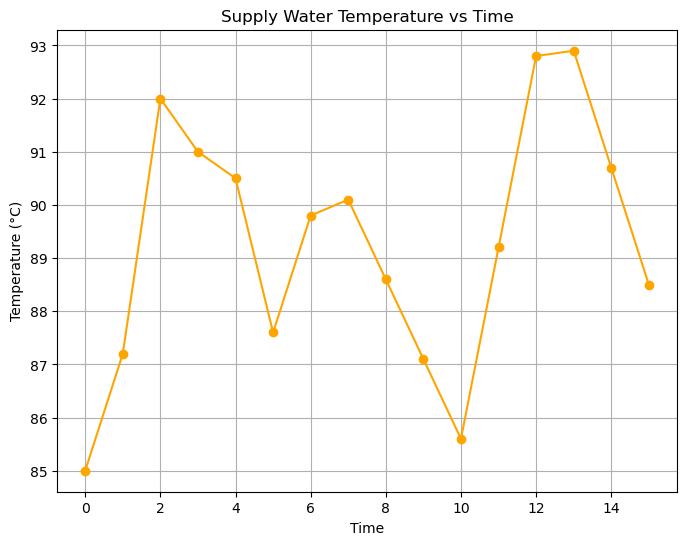

In [18]:
plt.figure(figsize=(8, 6))
plt.plot(data.index, data['Supply water temperature'], marker='o', linestyle='-', color='orange')
plt.title('Supply Water Temperature vs Time')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

Plot for Heat Demand vs Time

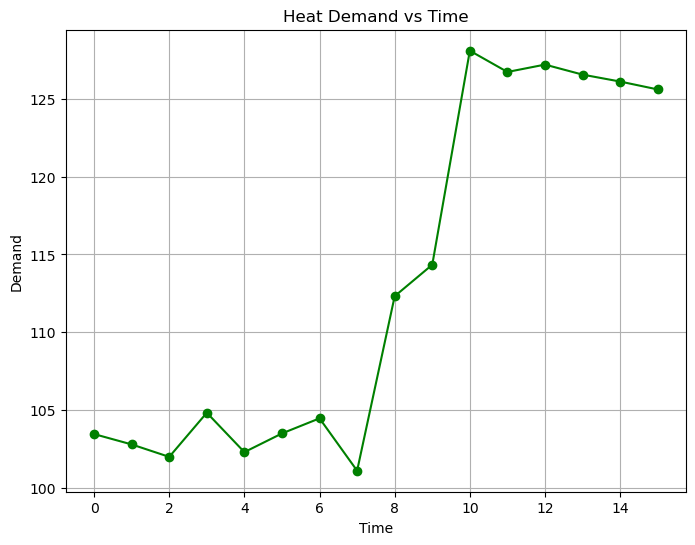

In [19]:
plt.figure(figsize=(8, 6))
plt.plot(data.index, data['Heat demand'], marker='o', linestyle='-', color='green')
plt.title('Heat Demand vs Time')
plt.xlabel('Time')
plt.ylabel('Demand')
plt.grid(True)
plt.show()

Plot for Electricity Generation vs Time

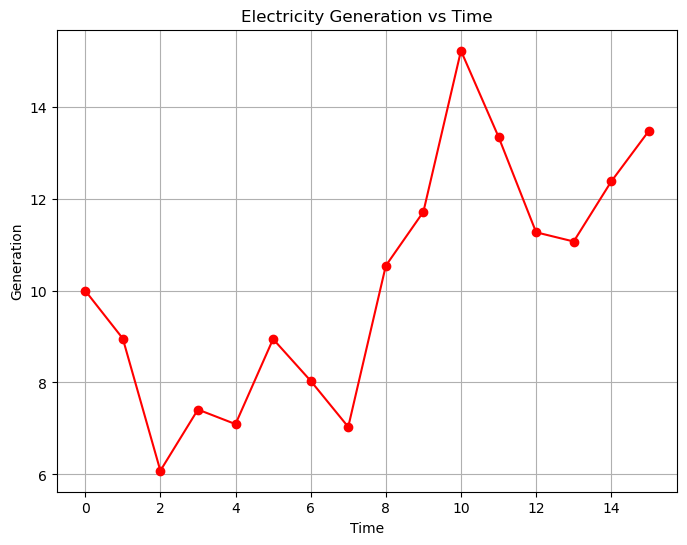

In [20]:
plt.figure(figsize=(8, 6))
plt.plot(data.index, data['p_el_mw'], marker='o', linestyle='-', color='red')
plt.title('Electricity Generation vs Time')
plt.xlabel('Time')
plt.ylabel('Generation')
plt.grid(True)
plt.show()

Plot for Fuel Total Heat Production vs Time

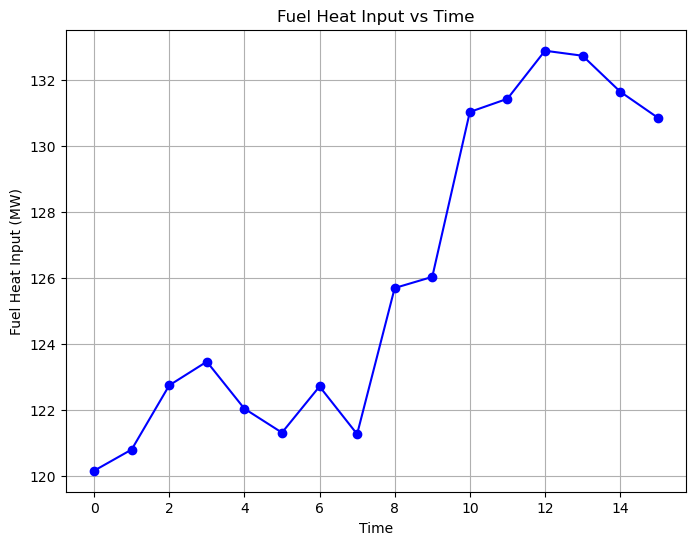

In [21]:
plt.figure(figsize=(8, 6))
plt.plot(data.index, data['q_fuel_mw'], marker='o', linestyle='-', color='blue')
plt.title('Fuel Heat Input vs Time')
plt.xlabel('Time')
plt.ylabel('Fuel Heat Input (MW)')
plt.grid(True)
plt.show()